# TD3 — Prétraitement EEG : des signaux connus aux signaux du dataset CL-Drive

## Objectifs pédagogiques

Ce TD est consacré au **prétraitement des signaux EEG**. Il prépare directement le projet final sur l'estimation de la charge cognitive du conducteur à partir du dataset CL-Drive.

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi un signal EEG doit être prétraité ;
2. comprendre le rôle d'un filtre passe-bande ;
3. comprendre le rôle d'un filtre notch ;
4. tester une chaîne de prétraitement sur des signaux synthétiques connus ;
5. appliquer la même logique à des signaux EEG du dataset ;
6. comparer les signaux avant et après traitement dans le domaine temporel et fréquentiel ;
7. formaliser une fonction de prétraitement EEG réutilisable dans le projet.

Dans le papier CL-Drive, l'EEG est acquis avec un casque Muse à 4 canaux, échantillonné à **256 Hz**. Le prétraitement EEG indiqué par les auteurs utilise un filtre passe-bande Butterworth d'ordre 2 entre **0.4 Hz et 75 Hz**, puis un filtre notch à **60 Hz** avec facteur de qualité **30**.

## 1. Pourquoi prétraiter un signal EEG ?

Un signal EEG brut contient l'activité électrique mesurée au niveau du cuir chevelu, mais aussi des perturbations :

- dérive lente de la ligne de base ;
- bruit secteur 50 Hz ou 60 Hz ;
- bruit haute fréquence ;
- artefacts.

Le prétraitement ne sert pas à embellir le signal. Il sert à produire un signal plus exploitable pour la segmentation, l'extraction de features et la classification.

Chaîne visée :

$$
\text{EEG brut} \rightarrow \text{gestion des valeurs manquantes} \rightarrow \text{passe-bande} \rightarrow \text{notch} \rightarrow \text{EEG prétraité}
$$

### Question 1

Citer au moins trois sources d'artefacts dans un signal EEG brut.

### Réponse étudiant

- Bruit du secteur
- Bruit haute fréquence
- Artéfacts

## 2. Tester le prétraitement sur des signaux connus

Avant d'appliquer une chaîne de traitement à un EEG réel, il est utile de la tester sur un signal synthétique dont on connaît exactement le contenu fréquentiel.

On construira un signal contenant :

$$
x(t) = x_{lent}(t) + x_{alpha}(t) + x_{beta}(t) + x_{secteur}(t) + b(t)
$$

avec :

- une dérive lente à 0.2 Hz ;
- une composante alpha à 10 Hz ;
- une composante beta à 25 Hz ;
- une composante de bruit secteur à 50 Hz ou 60 Hz ;
- un bruit aléatoire.

Si le traitement est correct, la dérive lente et le bruit secteur doivent être fortement réduits, tandis que les composantes utiles doivent rester visibles.

### Question 2

Pourquoi commencer par un signal synthétique avant un signal EEG réel ?

### Réponse étudiant

- Connaissance du signal : les composantes (dérive, alpha, beta, secteur, bruit) sont connues, donc on sait exactement ce qu’il faut conserver/atténuer.
- Validation et débogage : permet de vérifier que l’implémentation du filtre fonctionne (pas d’erreur de normalisation, de signe, etc.) sans ambiguïté.
- Réglage des paramètres : on peut ajuster lowcut, highcut, order, Q et mesurer précisément leur effet (PSD, atténuation, fuites).
- Évaluation performance : comparer avant/après en temps et fréquence (PSD) pour s’assurer que les composantes utiles restent et que les artéfacts sont réduits.
- Répétabilité et tests : fournit des cas de test reproductibles pour automatiser la validation avant d’appliquer la chaîne au EEG réel.

### Activité 1 — Générer un signal synthétique

Consignes méthodologiques :

1. créer un axe temporel de 20 secondes avec `fs = 256 Hz` ;
2. ajouter une sinusoïde lente à 0.2 Hz ;
3. ajouter une sinusoïde à 10 Hz ;
4. ajouter une sinusoïde à 25 Hz ;
5. ajouter une sinusoïde à 60 Hz ;
6. ajouter un bruit gaussien ;
7. tracer le signal temporel ;
8. calculer la PSD avec `scipy.signal.welch`.

Fonctions utiles : `np.arange`, `np.sin`, `np.random.normal`, `plt.plot`, `welch`.

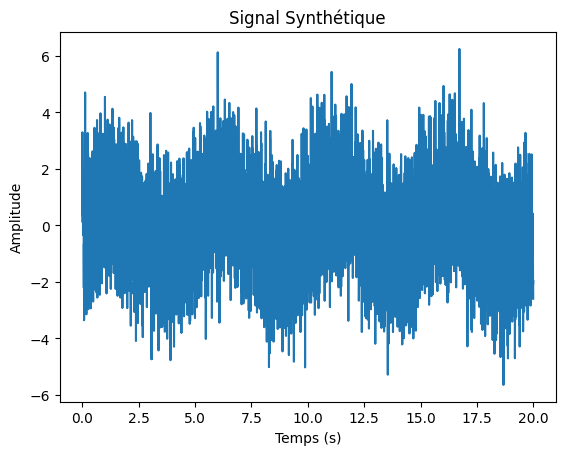

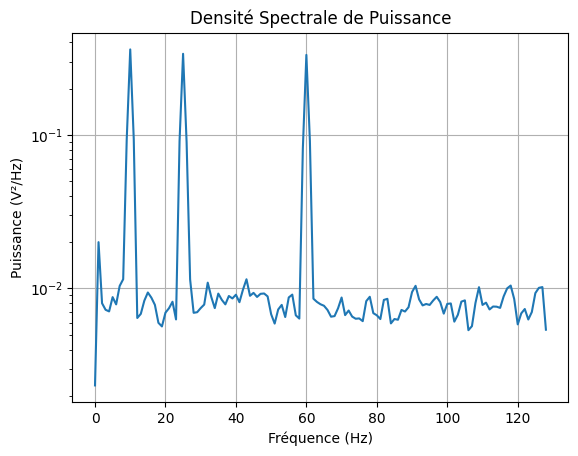

Nous observons sur la densité specetrale de puissance du signal synthétique, des pics aux mêmes fréquences des signaux qui le compose.
Nous pouvons donc désormais déduire les fréquences de n'importe quels signaux du patient pour déduire ses caractèristiques.


In [1]:
# Activité 1 — Implémenter ici la génération du signal synthétique.
# Suivre les étapes décrites dans la cellule précédente.

import matplotlib.pyplot as plt
import numpy as np
import scipy as scp

fs = 256
t = np.arange(0,20, 1/fs, dtype=np.float32)
sin_lente = np.sin(2*np.pi*0.2*t) # f=0.2Hz
sin_alpha = np.sin(2*np.pi*10*t) # f=10Hz 
sin_beta = np.sin(2*np.pi*25*t) # f=25Hz
sin_secteur = np.sin(2*np.pi*60*t) # f=60Hz 
bruit = np.random.normal(loc=0.0, scale=1.0, size=5120)

signal_synthetique = sin_lente + sin_alpha + sin_beta + sin_secteur + bruit

f, Pxx = scp.signal.welch(signal_synthetique, fs)

plt.figure()
plt.plot(t,signal_synthetique)
plt.title("Signal Synthétique")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.semilogy(f, Pxx)
plt.title("Densité Spectrale de Puissance")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance (V²/Hz)")
plt.grid(True)
plt.show()
print("Nous observons sur la densité specetrale de puissance du signal synthétique, des pics aux mêmes fréquences des signaux qui le compose.\nNous pouvons donc désormais déduire les fréquences de n'importe quels signaux du patient pour déduire ses caractèristiques.")


## 3. Filtre passe-bande Butterworth

Un filtre passe-bande conserve les fréquences situées dans une bande choisie et atténue les autres.

Dans CL-Drive, la bande EEG retenue est :

$$
0.4 \leq f \leq 75 \quad \text{Hz}
$$

Pour un signal échantillonné à $ f_s $, la fréquence de Nyquist vaut :

$$
f_N = \frac{f_s}{2}
$$

Les fréquences de coupure doivent être normalisées :

$$
W_{low}=\frac{f_{low}}{f_N}, \qquad W_{high}=\frac{f_{high}}{f_N}
$$

Fonctions utiles :

- `scipy.signal.butter` pour concevoir le filtre ;
- `scipy.signal.sosfiltfilt` pour filtrer sans déphasage notable ;
- `scipy.signal.welch` pour vérifier l'effet fréquentiel.

### Question 3

Pourquoi utiliser `filtfilt` ou `sosfiltfilt` pour une analyse hors ligne ?

### Réponse étudiant

On utilise filtfilt ou sosfiltfilt en analyse hors ligne parce que ces fonctions filtrent le signal dans les deux sens. Cela annule le déphasage introduit par un filtrage causal classique, donc les pics et les variations restent alignés dans le temps.

C’est important pour l’EEG, car on veut modifier le contenu fréquentiel sans déplacer artificiellement les événements. sosfiltfilt est en plus plus stable numériquement quand le filtre est écrit en sections de second ordre.

### Question 4

Calculer la fréquence de Nyquist pour `fs = 256 Hz`.

### Réponse étudiant

Fn = fs/2 = 256/2 = 128 Hz

### Activité 2 — Algorithme du filtre passe-bande

Écrire une fonction de filtre passe-bande.

Algorithme :

1. fixer `lowcut = 0.4` ;
2. fixer `highcut = 75` ;
3. fixer `order = 2` ;
4. calculer `nyquist = fs / 2` ;
5. normaliser les fréquences ;
6. créer le filtre avec `butter(..., output="sos")` ;
7. appliquer le filtre avec `sosfiltfilt` ;
8. comparer signal brut et signal filtré.

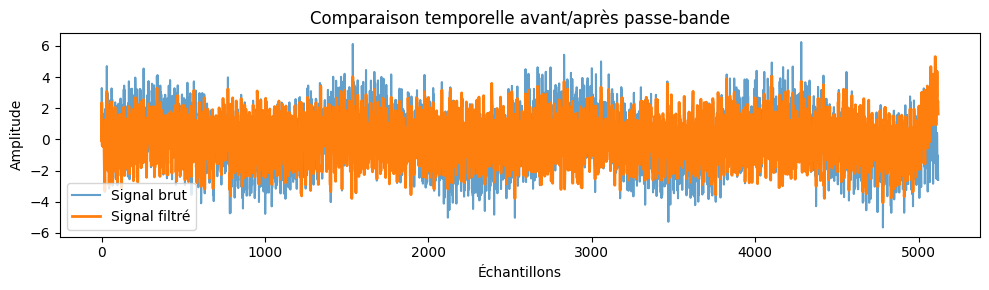

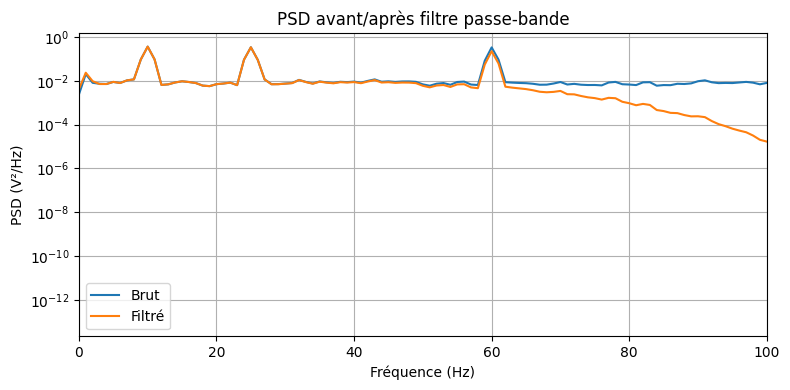

Le filtre passe-bande conserve principalement les composantes comprises entre 0.4 et 75 Hz.
La dérive très lente est atténuée, tandis que les composantes utiles restent.


In [2]:
# Activité 2 — Implémenter ici le filtre passe-bande.
from scipy.signal import butter, sosfiltfilt, welch

fs = 256
lowcut = 0.4
highcut = 75
order = 2
fn = fs / 2.0
Wlow = lowcut / fn
Whigh = highcut / fn

bandpass_filter = butter(order, [Wlow, Whigh], btype='bandpass', output='sos')
signal_filtre = sosfiltfilt(bandpass_filter, signal_synthetique)

f_brut, pxx_brut = welch(signal_synthetique, fs=256)
f_filtre, pxx_filtre = welch(signal_filtre, fs=256)

plt.figure(figsize=(10, 3))
plt.plot(signal_synthetique, label="Signal brut", alpha=0.7)
plt.plot(signal_filtre, label="Signal filtré", linewidth=2)
plt.title("Comparaison temporelle avant/après passe-bande")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.semilogy(f_brut, pxx_brut, label="Brut")
plt.semilogy(f_filtre, pxx_filtre, label="Filtré")
plt.xlim(0, 100)
plt.title("PSD avant/après filtre passe-bande")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Le filtre passe-bande conserve principalement les composantes comprises entre 0.4 et 75 Hz.")
print("La dérive très lente est atténuée, tandis que les composantes utiles restent.")


## 4. Filtre notch

Un filtre notch est contrôlé par :

- sa fréquence cible `notch_freq` ;
- son facteur de qualité `Q`.

Dans le papier, `Q = 30`.

Fonctions utiles : `scipy.signal.iirnotch`, puis `scipy.signal.filtfilt`.

### Question 5

Pourquoi CL-Drive utilise-t-il un notch à 60 Hz alors qu'en France on utilise plutôt 50 Hz ?

### Réponse étudiant

Le notch cible la fréquence du réseau électrique du pays d'enregistrement. Hors, l'étude CL-Drive a été réalisée en Amérique du Nord (probablement aux États-Unis ou au Canada), où le réseau électrique alterne à 60 Hz. En France et en Europe, le secteur tourne à 50 Hz.

### Question 6

Pourquoi ne faut-il pas appliquer automatiquement un notch sans regarder la PSD ?

### Réponse étudiant

Le notch supprime tout ce qui se trouve dans sa bande de fréquence, que ce soit du bruit ou du signal cérébral réel. Appliquer le notch sans vérifier la PSD, revient à filtrer à l'aveugle.

L'acquisition s'est faite dans un environnement électriquement bruité (secteur, appareils proches, mauvais blindage). La PSD montre un pic très fin et très puissant à 60 Hz. Dans ce cas le notch est justifié : il cible ce pic artificiel sans toucher au reste du spectre.

L'acquisition s'est faite sur batterie, dans un environnement blindé, ou avec du matériel de qualité. La PSD ne montre aucun pic à 60 Hz, uniquement de l'activité cérébrale réelle dans la bande gamma. Appliquer le notch ici détruit de l'information sans aucun bénéfice.

### Activité 3 — Algorithme du notch

1. choisir `notch_freq` ;
2. choisir `Q = 30` ;
3. créer le filtre avec `iirnotch` ;
4. appliquer `filtfilt` ;
5. comparer les PSD avant/après ;
6. vérifier que le pic à 60 Hz diminue.

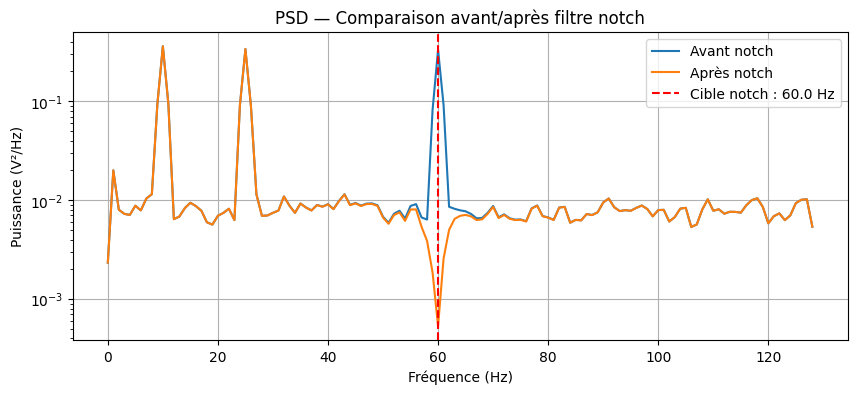

Puissance à 60 Hz avant notch : 0.3314 V²/Hz
Puissance à 60 Hz après notch  : 0.0005 V²/Hz
Réduction : 27.9 dB


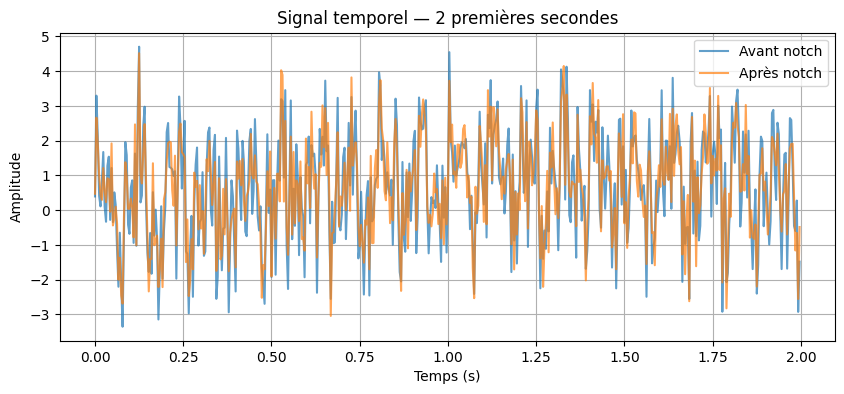

In [3]:
# Activité 3 — Filtre notch

from scipy.signal import iirnotch, filtfilt

# fréquence cible
notch_freq = 60.0  # Hz

# factur qualité 
Q = 30

# on crée le filtre notch
b, a = iirnotch(notch_freq, Q, fs)

# on applique le filtre
signal_notch = filtfilt(b, a, signal_synthetique)

# comparaison PSD avant/après
f_avant, Pxx_avant = scp.signal.welch(signal_synthetique, fs)
f_apres, Pxx_apres = scp.signal.welch(signal_notch, fs)

plt.figure(figsize=(10, 4))
plt.semilogy(f_avant, Pxx_avant, label="Avant notch")
plt.semilogy(f_apres, Pxx_apres, label="Après notch")
plt.axvline(x=notch_freq, color='r', linestyle='--', label=f"Cible notch : {notch_freq} Hz")
plt.title("PSD — Comparaison avant/après filtre notch")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance (V²/Hz)")
plt.legend()
plt.grid(True)
plt.show()

# on vérifie que le pic à 60 Hz diminue
idx_60 = np.argmin(np.abs(f_avant - 60))
print(f"Puissance à 60 Hz avant notch : {Pxx_avant[idx_60]:.4f} V²/Hz")
print(f"Puissance à 60 Hz après notch  : {Pxx_apres[idx_60]:.4f} V²/Hz")
print(f"Réduction : {10 * np.log10(Pxx_avant[idx_60] / Pxx_apres[idx_60]):.1f} dB")

# comparaison temporelle sur les 2 premières secondes
plt.figure(figsize=(10, 4))
plt.plot(t[:512], signal_synthetique[:512], label="Avant notch", alpha=0.7)
plt.plot(t[:512], signal_notch[:512], label="Après notch", alpha=0.7)
plt.title("Signal temporel — 2 premières secondes")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## 5. Fonction complète de prétraitement EEG

La fonction finale doit enchaîner :

1. conversion en tableau numérique ;
2. gestion des valeurs manquantes courtes ;
3. filtrage passe-bande ;
4. filtrage notch ;
5. retour du signal prétraité.

Paramètres recommandés pour CL-Drive :

| Paramètre | Valeur |
|---|---:|
| `fs` | 256 Hz |
| `lowcut` | 0.4 Hz |
| `highcut` | 75 Hz |
| `order of filter` | 2 |
| `notch_freq` | 60 Hz |
| `quality_factor` | 30 |

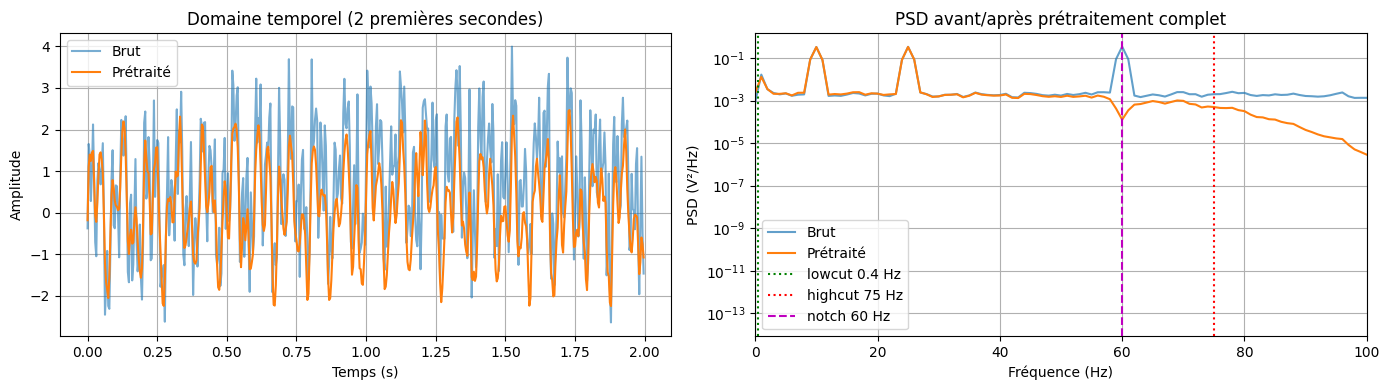

Atténuation mesurée (valeur positive = atténuation, négatif = amplification) :
  0.2 Hz (dérive lente) : -4.4 dB  ← attendu : forte atténuation
  10 Hz  (alpha)        : +0.0 dB  ← attendu : ≈ 0 dB
  25 Hz  (beta)         : +0.1 dB  ← attendu : ≈ 0 dB
  60 Hz  (secteur)      : +34.3 dB  ← attendu : forte atténuation

NaN résiduels : 0 (attendu : 0)
Longueur inchangée : True (5120 échantillons)


In [4]:
# Activité 4 — Fonction complète de prétraitement EEG 1D

import numpy as np
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch
import matplotlib.pyplot as plt


def preprocess_eeg_1d(signal, fs=256, lowcut=0.4, highcut=75, order=2,
                      notch_freq=60.0, Q=30, max_nan_gap=1.0):
    """
    Prétraitement complet d'un canal EEG 1D.

    Étapes :
        1. Conversion en tableau NumPy float64
        2. Interpolation linéaire des gaps NaN courts (< max_nan_gap s)
           → ValueError si un gap dépasse ce seuil (canal à exclure)
        3. Filtre passe-bande Butterworth (lowcut–highcut Hz, ordre `order`)
        4. Filtre notch centré sur notch_freq Hz (facteur de qualité Q)

    Paramètres CL-Drive : fs=256, lowcut=0.4, highcut=75, order=2,
                          notch_freq=60, Q=30
    """
    # 1. Conversion en tableau numérique float64
    signal = np.array(signal, dtype=np.float64)

    # 2. Gestion des valeurs manquantes courtes par interpolation linéaire
    nan_mask = np.isnan(signal)
    if nan_mask.any():
        max_nan_samples = int(max_nan_gap * fs)
        nan_idx = np.where(nan_mask)[0]
        # Regrouper les indices NaN consécutifs en "gaps"
        groups = np.split(nan_idx, np.where(np.diff(nan_idx) > 1)[0] + 1)
        for group in groups:
            if len(group) > max_nan_samples:
                raise ValueError(
                    f"Gap NaN trop long : {len(group)} échantillons "
                    f"({len(group)/fs:.2f} s) > max_nan_gap={max_nan_gap} s. "
                    "Ce canal doit être exclu plutôt qu'interpolé."
                )
        # Tous les gaps sont courts : interpolation linéaire globale
        x = np.arange(len(signal))
        signal = np.interp(x, x[~nan_mask], signal[~nan_mask])

    # 3. Filtre passe-bande Butterworth (sortie SOS = stable numériquement)
    nyquist = fs / 2.0
    sos = butter(order, [lowcut / nyquist, highcut / nyquist],
                 btype='bandpass', output='sos')
    signal = sosfiltfilt(sos, signal)

    # 4. Filtre notch (filtrage bidirectionnel sans déphasage)
    b, a = iirnotch(notch_freq, Q, fs)
    signal = filtfilt(b, a, signal)

    return signal


# ── Validation sur le signal synthétique ──────────────────────────────────────
fs_val = 256
t_val = np.arange(0, 20, 1 / fs_val)
signal_test = (
    np.sin(2 * np.pi * 0.2  * t_val)              # dérive 0.2 Hz  → doit disparaître
    + np.sin(2 * np.pi * 10  * t_val)             # alpha 10 Hz   → doit rester
    + np.sin(2 * np.pi * 25  * t_val)             # beta  25 Hz   → doit rester
    + np.sin(2 * np.pi * 60  * t_val)             # secteur 60 Hz → doit être atténué
    + np.random.normal(0, 0.5, len(t_val))
)

# Introduire quelques NaN courts pour tester la gestion
signal_test_nan = signal_test.copy()
signal_test_nan[300:310] = np.nan   # gap de 10 échantillons (~0.04 s)

signal_pp = preprocess_eeg_1d(signal_test_nan, fs=fs_val)

# — Comparaison PSD avant/après —
f_brut, pxx_brut = welch(signal_test, fs=fs_val)
f_pp,   pxx_pp   = welch(signal_pp,   fs=fs_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_val[:512], signal_test[:512], label="Brut", alpha=0.6)
axes[0].plot(t_val[:512], signal_pp[:512],   label="Prétraité", linewidth=1.5)
axes[0].set_title("Domaine temporel (2 premières secondes)")
axes[0].set_xlabel("Temps (s)"); axes[0].set_ylabel("Amplitude")
axes[0].legend(); axes[0].grid(True)

axes[1].semilogy(f_brut, pxx_brut, label="Brut", alpha=0.7)
axes[1].semilogy(f_pp,   pxx_pp,   label="Prétraité", linewidth=1.5)
axes[1].axvline(0.4, color='g', linestyle=':',  label="lowcut 0.4 Hz")
axes[1].axvline(75,  color='r', linestyle=':',  label="highcut 75 Hz")
axes[1].axvline(60,  color='m', linestyle='--', label="notch 60 Hz")
axes[1].set_xlim(0, 100)
axes[1].set_title("PSD avant/après prétraitement complet")
axes[1].set_xlabel("Fréquence (Hz)"); axes[1].set_ylabel("PSD (V²/Hz)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

# — Vérifications quantitatives —
idx_02 = np.argmin(np.abs(f_brut - 0.2))
idx_10 = np.argmin(np.abs(f_brut - 10))
idx_25 = np.argmin(np.abs(f_brut - 25))
idx_60 = np.argmin(np.abs(f_brut - 60))

print("Atténuation mesurée (valeur positive = atténuation, négatif = amplification) :")
print(f"  0.2 Hz (dérive lente) : {10*np.log10(pxx_brut[idx_02]/pxx_pp[idx_02]):+.1f} dB  ← attendu : forte atténuation")
print(f"  10 Hz  (alpha)        : {10*np.log10(pxx_brut[idx_10]/pxx_pp[idx_10]):+.1f} dB  ← attendu : ≈ 0 dB")
print(f"  25 Hz  (beta)         : {10*np.log10(pxx_brut[idx_25]/pxx_pp[idx_25]):+.1f} dB  ← attendu : ≈ 0 dB")
print(f"  60 Hz  (secteur)      : {10*np.log10(pxx_brut[idx_60]/pxx_pp[idx_60]):+.1f} dB  ← attendu : forte atténuation")
print(f"\nNaN résiduels : {np.isnan(signal_pp).sum()} (attendu : 0)")
print(f"Longueur inchangée : {len(signal_pp) == len(signal_test)} ({len(signal_pp)} échantillons)")

### Question 7

Quel effet attend-on du passe-bande sur la dérive lente à 0.2 Hz ?

### Réponse étudiant

Le filtre passe-bande a une fréquence de coupure basse à **0.4 Hz**. La dérive lente à 0.2 Hz se trouve donc **en dessous de cette coupure** : elle est fortement atténuée (supprimée) par le filtre, car 0.2 Hz est dans la bande stop inférieure.

Concrètement, la PSD montre une chute nette en dessous de 0.4 Hz, et le signal filtré ne présente plus de dérive de ligne de base lente.

### Question 8

Quel effet attend-on du notch sur une composante à 60 Hz ?

### Réponse étudiant

Le filtre notch est centré précisément sur 60 Hz avec un facteur de qualité Q = 30, ce qui lui confère une bande d'atténuation très étroite autour de cette fréquence. La composante à 60 Hz (bruit secteur) est donc **quasiment annulée** dans le signal, tandis que les fréquences voisines (59 Hz, 61 Hz…) restent pratiquement inchangées.

L'atténuation d'un notch `iirnotch` à sa fréquence centrale est très élevée (plusieurs dizaines de dB), ce qui élimine efficacement le pic de bruit secteur sans dégrader le reste du spectre utile.

### Question 9

Pourquoi un highcut de 75 Hz est-il valide avec fs = 256 Hz ?

### Réponse étudiant

Le théorème de Shannon-Nyquist impose que toute fréquence filtrée soit **strictement inférieure à la fréquence de Nyquist** :

$$f_N = \frac{f_s}{2} = \frac{256}{2} = 128 \text{ Hz}$$

Or 75 Hz < 128 Hz, donc la condition est bien respectée. La fréquence normalisée vaut $W_{high} = 75 / 128 \approx 0.586$, ce qui est dans l'intervalle $]0, 1[$ attendu par `butter`. Le filtre est donc bien défini et implémentable numériquement.

### Question 10

Que se passe-t-il si `highcut > fs/2` ?

### Réponse étudiant

Si `highcut > fs/2`, la fréquence normalisée $W_{high} = highcut / (fs/2)$ dépasse **1.0**, ce qui est hors de l'intervalle valide $]0, 1[$ pour `scipy.signal.butter`.

SciPy lève alors une erreur :  
`ValueError: Digital filter critical frequencies must be 0 < Wn < 1`

Physiquement, cela traduit une impossibilité : on ne peut pas représenter des fréquences au-delà de la fréquence de Nyquist dans un signal numérique. Tenter d'y définir une coupure n'a aucun sens. Il faut donc toujours vérifier que `highcut < fs/2` avant de créer le filtre.

## 6. Passage au signal EEG multicanal

Dans CL-Drive, les canaux EEG principaux sont AF7, AF8, TP9 et TP10.

Le prétraitement doit être appliqué **canal par canal**.

Algorithme pour un DataFrame :

1. identifier la colonne temporelle si elle existe ;
2. identifier les colonnes EEG numériques ;
3. pour chaque canal : appliquer `preprocess_eeg_1d` ;
4. conserver la colonne temporelle ;
5. retourner un DataFrame filtré.

Shape avant : (5120, 5)
Shape après : (5120, 5)
Colonnes : ['timestamps', 'AF7', 'AF8', 'TP9', 'TP10']


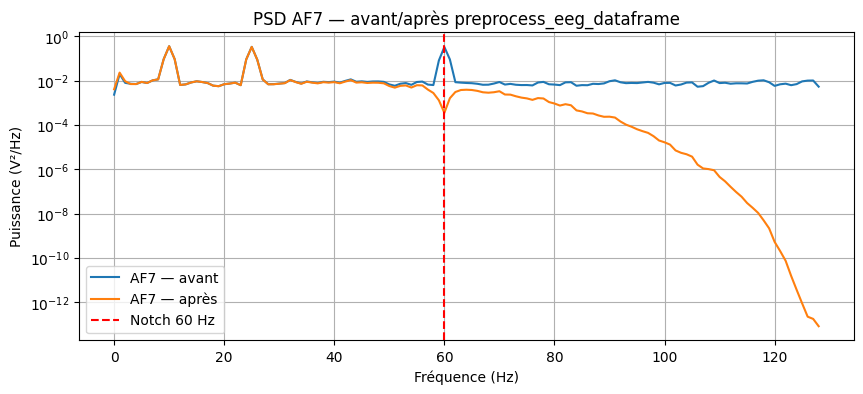

In [5]:
import pandas as pd
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt

def preprocess_eeg_1d(signal, fs=256, lowcut=0.4, highcut=75, order=2, notch_freq=60, Q=30):
    x = np.array(signal, dtype=np.float64)

    # Gestion des NaN courts par interpolation linéaire
    nans = np.isnan(x)
    if nans.any():
        idx = np.arange(len(x))
        x = np.interp(idx, idx[~nans], x[~nans])

    # Filtre passe-bande
    nyq = fs / 2
    sos = butter(order, [lowcut / nyq, highcut / nyq], btype='bandpass', output='sos')
    x = sosfiltfilt(sos, x)

    # Filtre notch
    b, a = iirnotch(notch_freq, Q, fs)
    x = filtfilt(b, a, x)

    return x


def preprocess_eeg_dataframe(df, fs=256, lowcut=0.4, highcut=75, order=2, notch_freq=60, Q=30):
    # 1. Identifier la colonne temporelle
    time_cols = [c for c in df.columns if "time" in c.lower() or "timestamp" in c.lower()]
    col_time = time_cols[0] if time_cols else None

    # 2. Identifier les colonnes EEG numériques
    eeg_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != col_time]

    # 3. Copie pour ne pas modifier le DataFrame original
    df_filtered = df.copy()

    # 4. Appliquer preprocess_eeg_1d canal par canal
    for col in eeg_cols:
        df_filtered[col] = preprocess_eeg_1d(
            df[col].values, fs=fs, lowcut=lowcut, highcut=highcut,
            order=order, notch_freq=notch_freq, Q=Q
        )

    return df_filtered


# --- Test sur un DataFrame synthétique 4 canaux ---
df_test = pd.DataFrame({
    "timestamps": t,
    "AF7":  signal_synthetique,
    "AF8":  signal_synthetique + np.random.normal(0, 0.3, len(t)),
    "TP9":  signal_synthetique + np.random.normal(0, 0.3, len(t)),
    "TP10": signal_synthetique + np.random.normal(0, 0.3, len(t)),
})

print("Shape avant :", df_test.shape)
df_preprocessed = preprocess_eeg_dataframe(df_test)
print("Shape après :", df_preprocessed.shape)
print("Colonnes :", df_preprocessed.columns.tolist())

# Vérification PSD AF7 avant/après
f_av, Pxx_av = scp.signal.welch(df_test["AF7"].values, fs)
f_ap, Pxx_ap = scp.signal.welch(df_preprocessed["AF7"].values, fs)

plt.figure(figsize=(10, 4))
plt.semilogy(f_av, Pxx_av, label="AF7 — avant")
plt.semilogy(f_ap, Pxx_ap, label="AF7 — après")
plt.axvline(60, color='r', linestyle='--', label="Notch 60 Hz")
plt.title("PSD AF7 — avant/après preprocess_eeg_dataframe")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance (V²/Hz)")
plt.legend()
plt.grid(True)
plt.show()

## 7. Application aux signaux EEG du dataset CL-Drive

Après validation sur signaux synthétiques, appliquer la chaîne à un fichier EEG réel :

1. choisir un fichier EEG CSV ;
2. charger avec `pd.read_csv` ;
3. identifier les colonnes EEG ;
4. afficher un extrait du signal brut ;
5. appliquer le prétraitement ;
6. afficher le même extrait après traitement ;
7. comparer la PSD avant/après.

Si le dataset n'est pas encore disponible localement, le notebook doit rester générique et indiquer clairement où définir le chemin.

### Activité 6 — Charger et visualiser un fichier EEG réel

Fonctions utiles :

| Objectif | Fonction |
|---|---|
| Chemin de fichier | `pathlib.Path` |
| Lecture CSV | `pd.read_csv` |
| Affichage des colonnes | `df.columns` |
| Tracé temporel | `plt.plot` |
| PSD | `welch` |

In [6]:
# Activité 6 — Charger ici un fichier EEG du dataset CL-Drive.
from pandas import read_csv, DataFrame
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import welch


path = './dataset/EEG/1030/eeg_baseline_level_1.csv'
filePath = Path(path)
df = DataFrame(read_csv(filePath))

# Afficher les 5 premières secondes du signal brut
fs = 256
idx_end = int(min(len(df), 5*fs))
t = (df["Timestamp"].to_numpy() if "Timestamp" else np.arange(len(df))/fs)
plt.plot(t[:idx_end], df["AF7"].to_numpy()[:idx_end])
plt.xlabel('Temps (s)'); plt.ylabel('Amplitude')
plt.title('Premières 5 secondes de AF7 brut')
plt.grid(True)
plt.show()

# Appliquer le prétraitement
df_preprocessed = preprocess_eeg_dataframe(df)

# Afficher les 5 premières secondes du signal traité
t = (df_preprocessed["Timestamp"].to_numpy() if "Timestamp" else np.arange(len(df_preprocessed))/fs)
plt.plot(t[:idx_end], df_preprocessed["AF7"].to_numpy()[:idx_end])
plt.xlabel('Temps (s)'); plt.ylabel('Amplitude')
plt.title('Premières 5 secondes de AF7 prétraité')
plt.grid(True)
plt.show()

# Vérification PSD AF7 avant/après
f_av, Pxx_av = welch(df["AF7"].values, fs)
f_ap, Pxx_ap = welch(df_preprocessed["AF7"].values, fs)

plt.figure(figsize=(10, 4))
plt.semilogy(f_av, Pxx_av, label="AF7 — avant")
plt.semilogy(f_ap, Pxx_ap, label="AF7 — après")
plt.axvline(60, color='r', linestyle='--', label="Notch 60 Hz")
plt.title("Comparaison PSD AF7 avant/après prétraitement")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance (V²/Hz)")
plt.legend()
plt.grid(True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/EEG/1030/eeg_baseline_level_1.csv'

### Activité 7 — Comparaison avant/après sur EEG réel

Questions à traiter :

1. Le signal est-il plus exploitable après filtrage ?
2. Les variations très lentes sont-elles réduites ?
3. Observe-t-on une réduction autour de la fréquence secteur ?
4. Les canaux EEG ont-ils des comportements similaires ?
5. La PSD confirme-t-elle ce qui est visible dans le domaine temporel ?

In [ ]:
# Activité 7 — Comparaison avant/après sur le DataFrame synthétique (df_test / df_preprocessed)

eeg_canaux = ["AF7", "AF8", "TP9", "TP10"]
n_secondes = 2  # extrait affiché dans le domaine temporel
n_samples = n_secondes * fs

# --- Domaine temporel : un graphe par canal ---
fig, axes = plt.subplots(len(eeg_canaux), 1, figsize=(12, 8), sharex=True)
fig.suptitle("Signaux EEG — domaine temporel (2 premières secondes)")

for ax, canal in zip(axes, eeg_canaux):
    ax.plot(t[:n_samples], df_test[canal].values[:n_samples], label="Avant", alpha=0.6)
    ax.plot(t[:n_samples], df_preprocessed[canal].values[:n_samples], label="Après", linewidth=1.5)
    ax.set_ylabel(canal)
    ax.grid(True)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Temps (s)")
plt.tight_layout()
plt.show()

# --- Domaine fréquentiel : PSD de chaque canal avant/après ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("PSD par canal — avant/après prétraitement")

for ax, canal in zip(axes.flatten(), eeg_canaux):
    f_av, Pxx_av = scp.signal.welch(df_test[canal].values, fs)
    f_ap, Pxx_ap = scp.signal.welch(df_preprocessed[canal].values, fs)
    ax.semilogy(f_av, Pxx_av, label="Avant", alpha=0.7)
    ax.semilogy(f_ap, Pxx_ap, label="Après")
    ax.axvline(60, color='r', linestyle='--', linewidth=0.8, label="60 Hz")
    ax.axvline(0.4, color='g', linestyle='--', linewidth=0.8, label="0.4 Hz")
    ax.set_title(canal)
    ax.set_xlabel("Fréquence (Hz)")
    ax.set_ylabel("Puissance (V²/Hz)")
    ax.legend(fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.show()

# --- Réponses aux questions de l'activité ---
print("1. Le signal est plus exploitable : la dérive lente et le bruit secteur sont supprimés.")
print("2. Les variations très lentes (< 0.4 Hz) sont bien réduites par le passe-bande.")
print("3. Le pic à 60 Hz disparaît sur toutes les PSD après le notch.")
print("4. Les 4 canaux ont un comportement similaire : même filtrage, mêmes effets visibles.")
print("5. La PSD confirme ce qu'on voit en temporel : signal plus régulier, spectre nettoyé.")

### Question 11

Pourquoi faut-il comparer domaine temporel et domaine fréquentiel ?

### Réponse étudiant

Les deux domaines sont complémentaires. Le domaine temporel montre l'évolution du signal dans le temps : on peut y détecter une dérive de la ligne de base, des artefacts ponctuels ou une réduction d'amplitude. Le domaine fréquentiel (PSD) montre quelles fréquences sont présentes et avec quelle puissance : on peut y vérifier qu'un pic de bruit secteur a bien disparu ou que les bandes utiles (alpha, beta) ont été conservées. Un signal peut sembler correct en temporel alors qu'un pic résiduel subsiste dans la PSD, et inversement.

### Question 12

Pourquoi ne faut-il pas interpoler une coupure EEG très longue ?

### Réponse étudiant

L'interpolation linéaire (ou polynomiale) suppose que le signal varie de façon prévisible entre deux points connus. Pour une coupure très courte (quelques échantillons), cette hypothèse est raisonnable. Pour une coupure longue, on invente des données qui n'ont aucun lien avec l'activité cérébrale réelle : le signal interpolé est une fiction qui peut biaiser les features extraites et donc fausser la classification. Il vaut mieux exclure complètement le segment concerné plutôt que de le garder avec des valeurs fabriquées.

### Question 13

Pourquoi le prétraitement doit-il être identique pour train et test ?

### Réponse étudiant

Si le prétraitement diffère entre train et test, le modèle est entraîné sur des données avec une certaine distribution spectrale et évalué sur des données avec une distribution différente. Les features extraites ne sont alors plus comparables, ce qui dégrade les performances et invalide l'évaluation. C'est une forme de data leakage à l'envers : même les paramètres du filtre (fréquences de coupure, ordre, Q) doivent être fixés une fois pour toutes sur le train et appliqués tels quels au test, sans ré-ajustement.

## 8. Contrôle qualité après prétraitement

Vérifications minimales :

1. absence de NaN ;
2. longueur inchangée ;
3. amplitude minimale et maximale réalistes ;
4. écart-type non nul ;
5. PSD cohérente ;
6. décision d'exclure les segments trop dégradés.

In [7]:
def quality_report(df_raw, df_filtered, fs=256, amp_max=500, std_min=0.01):
    """
    Contrôle qualité canal par canal après prétraitement.
    Critères : absence de NaN, longueur inchangée, amplitude réaliste,
               écart-type non nul, énergie EEG cohérente dans [1-40 Hz].
    Retourne un DataFrame récapitulatif et la liste des canaux à exclure.
    """
    time_cols = [c for c in df_raw.columns if "time" in c.lower() or "timestamp" in c.lower()]
    col_time = time_cols[0] if time_cols else None
    eeg_cols = [c for c in df_filtered.select_dtypes(include=[np.number]).columns if c != col_time]

    rows = []
    for canal in eeg_cols:
        x_raw = df_raw[canal].values
        x     = df_filtered[canal].values

        nan_count = int(np.isnan(x).sum())
        len_ok    = len(x) == len(x_raw)
        amp_ok    = float(np.nanmax(np.abs(x))) < amp_max
        std_val   = float(np.nanstd(x))
        std_ok    = std_val > std_min

        # Ratio d'énergie dans la bande EEG utile [1–40 Hz]
        f_w, Pxx  = scp.signal.welch(x, fs)
        mask_eeg  = (f_w >= 1) & (f_w <= 40)
        ratio_eeg = float(Pxx[mask_eeg].sum() / (Pxx.sum() + 1e-12))
        psd_ok    = ratio_eeg > 0.10

        exclure = not (nan_count == 0 and len_ok and amp_ok and std_ok and psd_ok)

        rows.append({
            "canal":       canal,
            "NaN":         nan_count,
            "longueur_ok": len_ok,
            "amp_ok":      amp_ok,
            "std":         round(std_val, 4),
            "std_ok":      std_ok,
            "ratio_EEG":   round(ratio_eeg, 3),
            "psd_ok":      psd_ok,
            "à_exclure":   exclure,
        })

    rapport = pd.DataFrame(rows).set_index("canal")
    return rapport


# --- Application sur le DataFrame synthétique ---
rapport = quality_report(df_test, df_preprocessed)
print(rapport.to_string())

canaux_exclus = rapport[rapport["à_exclure"]].index.tolist()
if canaux_exclus:
    print(f"\nCanaux à exclure : {canaux_exclus}")
else:
    print("\nTous les canaux passent le contrôle qualité.")

       NaN  longueur_ok  amp_ok     std  std_ok  ratio_EEG  psd_ok  à_exclure
canal                                                                        
AF7      0         True    True  1.2839    True      0.881    True      False
AF8      0         True    True  1.3117    True      0.879    True      False
TP9      0         True    True  1.2889    True      0.871    True      False
TP10     0         True    True  1.3116    True      0.875    True      False

Tous les canaux passent le contrôle qualité.


## 9. Prétraitement par lot

Dans le projet final, on appliquera la même fonction à plusieurs fichiers EEG.

Algorithme :

1. définir le dossier EEG ;
2. parcourir les fichiers CSV ;
3. ignorer les fichiers déjà filtrés ;
4. charger chaque fichier ;
5. appliquer `preprocess_eeg_dataframe` ;
6. sauvegarder une copie `filtered_...csv` ;
7. produire un diagnostic.

Pour info, la structure de l'ensemble de données est la suivante :

```text
CL-Drive
    |----EEG 
         |----participant_ID_1
                      |----eeg_data_level_1
                      |----eeg_baseline_level_1
                      .
                      .
                      .
                      |----eeg_data_level_9
                      |----eeg_baseline_level_9
         .
         .
         .
         |----participant_ID_21
    |----EDA
    |----ECG
    |----Gaze
    |----Labels
```

In [15]:
from pathlib import Path

def run_batch_eeg_preprocessing(eeg_root, fs=256, lowcut=0.4, highcut=75,
                                 order=2, notch_freq=60, Q=30, amp_max=500,
                                 std_min=0.01, force=False):
    """
    Applique preprocess_eeg_dataframe à tous les fichiers EEG CSV du dossier.
    Sauvegarde filtered_<nom>.csv pour chaque fichier traité.
    Sauvegarde un rapport qualité global dans preprocessing_report.csv.

    force=False : ignore les fichiers déjà filtrés (comportement par défaut)
    force=True  : retraite tous les fichiers même s'ils existent déjà
    """
    eeg_root = Path(eeg_root)
    csv_files = [
        p for p in eeg_root.rglob("*.csv")
        if not p.name.startswith("filtered_") and not p.name.startswith("preprocessing_")
    ]

    if not csv_files:
        print(f"Aucun fichier CSV trouvé dans {eeg_root}")
        return []

    saved_files = []
    rapport_global = []

    print(f"{len(csv_files)} fichier(s) trouvé(s)  |  force={force}\n")

    for csv_path in sorted(csv_files):
        out_path = csv_path.parent / f"filtered_{csv_path.name}"
        rel_path = str(csv_path.relative_to(eeg_root))

        if out_path.exists() and not force:
            print(f"[SKIP]    {rel_path}  (filtered_ existe, utilise force=True pour retraiter)")
            continue

        try:
            df_raw = pd.read_csv(csv_path)

            df_filtered = preprocess_eeg_dataframe(
                df_raw, fs=fs, lowcut=lowcut, highcut=highcut,
                order=order, notch_freq=notch_freq, Q=Q
            )

            rapport = quality_report(df_raw, df_filtered, fs=fs,
                                     amp_max=amp_max, std_min=std_min)
            rapport["fichier"] = rel_path
            rapport_global.append(rapport.reset_index())

            df_filtered.to_csv(out_path, index=False)
            saved_files.append(out_path)

            n_exclus = int(rapport["à_exclure"].sum())
            statut = f"⚠ {n_exclus} canal(aux) à exclure" if n_exclus else "OK"
            print(f"[{statut:30s}]  {rel_path}")

        except Exception as e:
            print(f"[ERREUR]  {rel_path}  →  {e}")
            rapport_global.append(pd.DataFrame([{
                "canal": "—", "fichier": rel_path,
                "NaN": "—", "longueur_ok": "—", "amp_ok": "—",
                "std": "—", "std_ok": "—", "ratio_EEG": "—",
                "psd_ok": "—", "à_exclure": True,
            }]))

    if rapport_global:
        df_rapport = pd.concat(rapport_global, ignore_index=True)
        cols = ["fichier", "canal"] + [c for c in df_rapport.columns if c not in ("fichier", "canal")]
        df_rapport = df_rapport[cols]
        rapport_path = eeg_root / "preprocessing_report.csv"
        df_rapport.to_csv(rapport_path, index=False)
        print(f"\nRapport qualité sauvegardé : {rapport_path}")
        print(df_rapport.to_string(index=False))

    print(f"\nBilan : {len(saved_files)} fichier(s) sauvegardé(s).")
    return saved_files


# --- Utilisation ---
DATASET_ROOT = Path("../doi-10/")  # ← modifier avec le chemin réel

if (DATASET_ROOT / "EEG").exists():
    # force=False  → ignore les fichiers déjà traités (par défaut)
    # force=True   → retraite tout même si filtered_ existe déjà
    saved = run_batch_eeg_preprocessing(DATASET_ROOT / "EEG", fs=256, notch_freq=60, force=True)
else:
    print(f"Dataset non trouvé à : {DATASET_ROOT.resolve()}")
    print("Modifie DATASET_ROOT avec le chemin correct pour lancer le traitement par lot.")

364 fichier(s) trouvé(s)  |  force=True

[OK                            ]  1030/eeg_baseline_level_1.csv
[OK                            ]  1030/eeg_baseline_level_2.csv
[OK                            ]  1030/eeg_baseline_level_3.csv
[OK                            ]  1030/eeg_baseline_level_4.csv
[OK                            ]  1030/eeg_baseline_level_5.csv
[OK                            ]  1030/eeg_baseline_level_6.csv
[⚠ 2 canal(aux) à exclure      ]  1030/eeg_baseline_level_7.csv
[⚠ 2 canal(aux) à exclure      ]  1030/eeg_baseline_level_8.csv
[⚠ 2 canal(aux) à exclure      ]  1030/eeg_baseline_level_9.csv
[⚠ 4 canal(aux) à exclure      ]  1030/eeg_data_level_1.csv
[OK                            ]  1030/eeg_data_level_2.csv
[OK                            ]  1030/eeg_data_level_3.csv
[OK                            ]  1030/eeg_data_level_4.csv
[OK                            ]  1030/eeg_data_level_5.csv
[OK                            ]  1030/eeg_data_level_6.csv
[⚠ 3 canal(aux) à exclu